In [2]:
import sys
import numpy as np

print("Interpreter:", sys.executable)
print("NumPy:", np.__version__)
print("NumPy file:", np.__file__)

Interpreter: C:\Users\olesk\anaconda3\envs\scrna-driver\python.exe
NumPy: 2.4.6
NumPy file: C:\Users\olesk\anaconda3\envs\scrna-driver\Lib\site-packages\numpy\__init__.py


# NSCLC tumor microenvironment: the malignant-cell landscape and the CAF stiffening bridge

v1 found the stiff niche in fibrotic lung, which is where nobody disputes that it exists. The
interesting question is whether a tumor does the same thing to the tissue around it, and whether its
cancer cells notice.

Two questions bridge v1 to the EGFR-mutant NSCLC drug-tolerance model, and they sit on opposite
sides of the same claim. Do tumor-associated fibroblasts (CAFs) rebuild the v1 stiffening niche in
the cancer stroma? And do malignant cells carry the PI3K-AKT and YAP mechanosensing program the
model assumes they carry? One asks who builds the niche, the other who responds to it. Kim answers
them very differently.

**Dataset.** Kim et al. 2020 (GSE131907): 11 tumor and 11 normal lung samples, roughly 88K cells,
run through the v1 pipeline with CNV-based malignant-cell calling (inferCNVpy) added.

**TL;DR**

- The CTHRC1⁺ stiffening niche reappears in NSCLC tumor stroma, and fibroblast-restricted DE says
  the fibroblasts are doing it per cell rather than simply arriving in greater numbers.
- The mechanotransduction response is not elevated in Kim's bulk treatment-naïve malignant cells.
- That second result is a landscape claim rather than a per-donor one, and the reason is worth
  stating up front. Kim's epithelial compartment is thin (most samples carry 100–500 epithelial
  cells) and the CNV score turns out to be confounded by sequencing depth (r = −0.8, characterized
  below). Malignant calling holds up at the cohort level; the rigorous tumor-intrinsic and persister
  test is deferred to Maynard, which is Smart-seq2 and cancer-cell-enriched.

## 1: Setup — load the CNV result and re-attach QC depth

The CNV object (`results_kim/cnv/cnv.h5ad`) carries log-normalized expression over roughly 20,350
genome-positioned genes, the authors' `cell_type`, and per cell `condition`, `donor_id`, `cnv_score`,
and `cnv_status`.

One thing it does not carry is sequencing depth. `total_counts` gets dropped during the inferCNV
concat, and depth turns out to be the most important covariate in this whole notebook, so the first
step is joining it back on by barcode from the QC files. That join needs the `-{batch}` suffix
`ad.concat` added stripped off first, which is what `strip` does below.

In [3]:
import re, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
from scipy.stats import mannwhitneyu
from pathlib import Path
import os

In [4]:
d = Path.cwd()
while not (d / "workflow").is_dir() and d != d.parent:
    d = d.parent
os.chdir(d)
print("repo root:", d)

repo root: C:\Users\olesk\repos\lung_stiffness_RNAseq


In [5]:

sc.settings.verbosity = 0
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

A = sc.read_h5ad("results_kim/cnv/cnv.h5ad")

# re-attach total_counts / pct_counts_mito from the QC files (dropped in the CNV concat)
# ad.concat(index_unique="-") appended -{batch} to every barcode; strip it to join back
strip = lambda s: re.sub(r"-\d+$", "", str(s))
qc = pd.concat([sc.read_h5ad(f, backed="r").obs for f in glob.glob("results_kim/qc/LUNG_*.h5ad")])
qc.index = [strip(b) for b in qc.index]
A.obs["_k"] = [strip(b) for b in A.obs_names]
for m in ["total_counts", "pct_counts_mito"]:
    if m in qc.columns:
        A.obs[m] = A.obs["_k"].map(qc[m].to_dict())

print(f"{A.n_obs:,} cells x {A.n_vars:,} genes")
print("cnv_status:", dict(A.obs['cnv_status'].value_counts()))

def score_sig(adata, genes, name):
    # score_genes on the subset of genes actually present (robust to symbol drift)
    present = [g for g in genes if g in adata.var_names]
    sc.tl.score_genes(adata, present, score_name=name)
    return present

87,832 cells x 20,350 genes
cnv_status: {'reference': np.int64(68690), 'other': np.int64(8271), 'malignant': np.int64(5592), 'normal_epithelium': np.int64(5279)}


## 2: The TME landscape (tumor against normal)

Before anything mechanistic, a look at what simply changes in the microenvironment: which cell types
skew tumor, which skew normal, and by how much. Orientation, not a test.

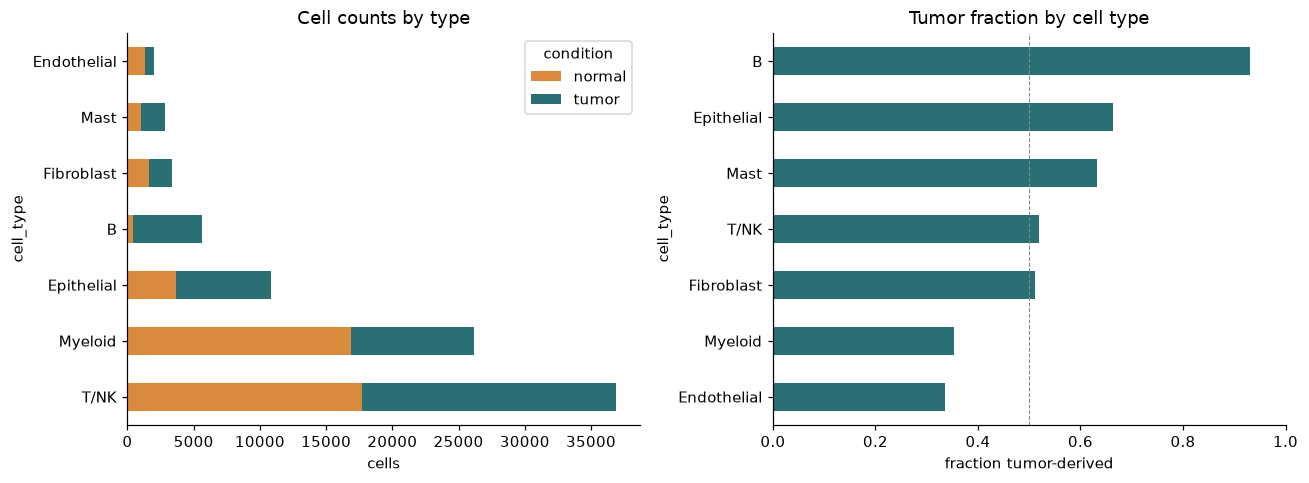

condition    normal  tumor  tumor_frac
cell_type                             
T/NK          17729  19127        0.52
Myeloid       16917   9252        0.35
Epithelial     3669   7202        0.66
B               396   5269        0.93
Fibroblast     1657   1735        0.51
Mast           1057   1818        0.63
Endothelial    1333    671        0.33


In [6]:
ctab = pd.crosstab(A.obs["cell_type"], A.obs["condition"])
ctab = ctab.loc[ctab.sum(1).sort_values(ascending=False).index]
frac = ctab.div(ctab.sum(1), axis=0)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ctab.plot(kind="barh", stacked=True, ax=ax[0], color={"normal":"#d98a3d","tumor":"#2a6f74"})
ax[0].set_title("Cell counts by type"); ax[0].set_xlabel("cells")
frac["tumor"].sort_values().plot(kind="barh", ax=ax[1], color="#2a6f74")
ax[1].axvline(0.5, ls="--", lw=.7, c="#888"); ax[1].set_xlim(0,1)
ax[1].set_title("Tumor fraction by cell type"); ax[1].set_xlabel("fraction tumor-derived")
plt.tight_layout(); plt.show()
print(ctab.assign(tumor_frac=frac["tumor"].round(2)).to_string())

**Read-out.** The compositional shift is there, and it can be compared per sample at 11 against 11.
B cells, epithelial cells, and mast cells skew toward tumor; endothelial and myeloid cells skew
toward normal. Two of those have obvious explanations, since tumors recruit B-cell infiltration and
malignant epithelium exists only in tumors by definition.

The epithelial skew is the one to follow. Anything tumor-enriched in the epithelial compartment is a
candidate cancer cell, but "enriched in tumor samples" is a claim about samples and not about cells,
and a tumor biopsy contains plenty of perfectly ordinary epithelium alongside the malignant kind.
The CNV step next makes the call cell by cell.

## 3: CNV-based malignant calling

inferCNVpy infers large-scale copy number from expression by smoothing across genes ordered along
each chromosome, using the immune compartment (T/NK, myeloid, B) as a diploid reference. An
epithelial cell that comes out aneuploid gets called malignant.

The useful property of this design is that it validates itself. Normal-lung epithelium is not cancer
and therefore has to score diploid, while tumor epithelium should spread toward aneuploid. Anything
else means the method is measuring something other than copy number. Holding onto that expectation
is what turns up the problem two cells from here.

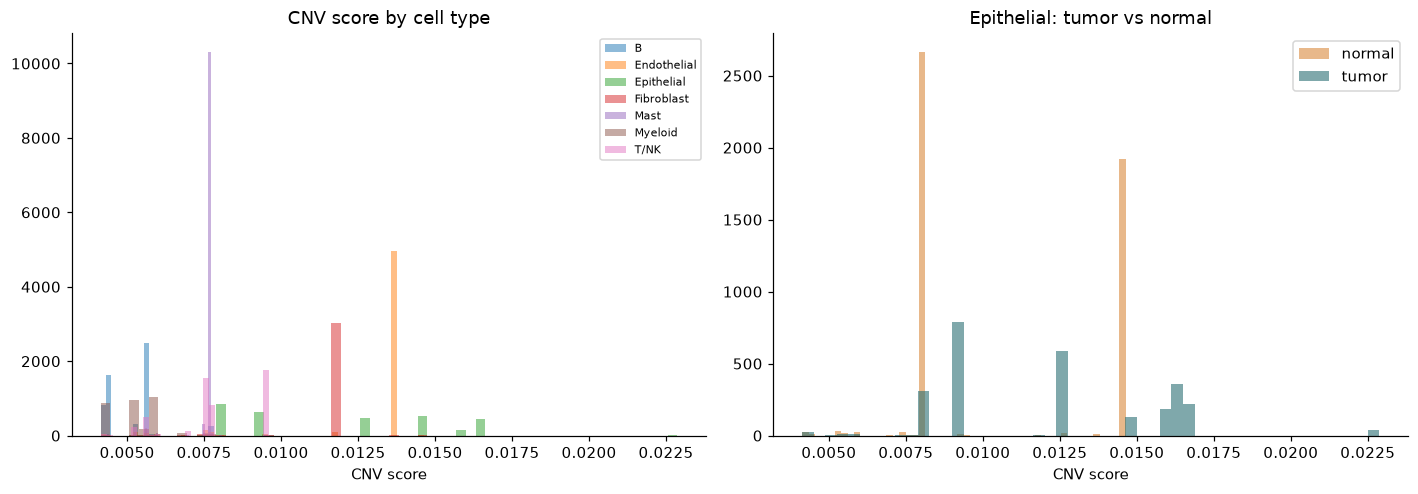

In [7]:
epi = A.obs[A.obs["cell_type"] == "Epithelial"].copy()

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
# (left) CNV score by cell type - validation that immune ref is low, epithelial spreads high
for ct, sub in A.obs.groupby("cell_type", observed=True):
    ax[0].hist(sub["cnv_score"], bins=60, alpha=.5, density=True, label=ct)
ax[0].set_xlabel("CNV score"); ax[0].set_title("CNV score by cell type"); ax[0].legend(fontsize=7)
# (right) epithelial tumor vs normal - the bimodal validation
for cond, c in [("normal","#d98a3d"), ("tumor","#2a6f74")]:
    ax[1].hist(epi.loc[epi.condition==cond,"cnv_score"], bins=50, alpha=.6, density=True, label=cond, color=c)
ax[1].set_xlabel("CNV score"); ax[1].set_title("Epithelial: tumor vs normal"); ax[1].legend()
plt.tight_layout(); plt.show()

**The validation mostly works.** Normal epithelium sits low, where diploid cells belong, and tumor
epithelium spreads high into the aneuploid range. That much is the expected picture.

The normal distribution has a tail, though, and the tail is where healthy lung cells are being
scored as aneuploid. Healthy lung is not secretly aneuploid, so something else is producing those
scores, and it is worth finding out what before trusting any fine-grained call built on top of them.
The answer turns out to be sequencing depth.

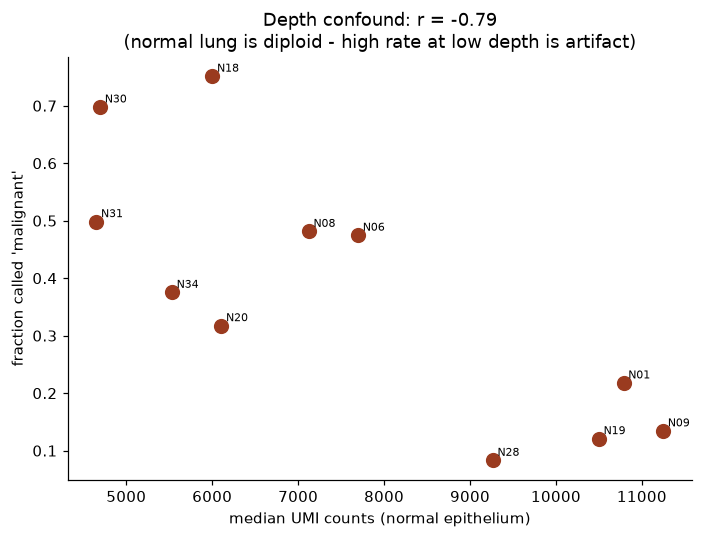

          malig_rate  median_counts    n
donor_id                                
LUNG_N18        0.75         6003.0  402
LUNG_N30        0.70         4697.0  334
LUNG_N31        0.50         4652.5  544
LUNG_N08        0.48         7125.0  293
LUNG_N06        0.47         7699.0  177
LUNG_N34        0.38         5533.0  653
LUNG_N20        0.32         6107.5  290
LUNG_N01        0.22        10788.0  193
LUNG_N09        0.13        11248.5  380
LUNG_N19        0.12        10501.0  174
LUNG_N28        0.08         9266.0  229


In [8]:
# the confound: malignant rate vs depth across normal samples.
# normal lung is diploid, so any correlation here is inferCNV reading coverage noise as CNV.
VALLEY = 0.0109   # density valley between diploid/aneuploid epithelial modes
epi["malig"] = epi["cnv_score"] > VALLEY
g = (epi[epi.condition=="normal"].groupby("donor_id", observed=True)
       .agg(malig_rate=("malig","mean"), median_counts=("total_counts","median"),
            n=("malig","size")).sort_values("malig_rate", ascending=False))

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(g["median_counts"], g["malig_rate"], s=80, c="#9a3b1f")
for s, r in g.iterrows():
    ax.annotate(s.replace("LUNG_",""), (r["median_counts"], r["malig_rate"]), fontsize=7, xytext=(3,3), textcoords="offset points")
ax.set_xlabel("median UMI counts (normal epithelium)"); ax.set_ylabel("fraction called 'malignant'")
ax.set_title(f"Depth confound: r = {g.malig_rate.corr(g.median_counts):.2f}\n(normal lung is diploid - high rate at low depth is artifact)")
plt.tight_layout(); plt.show()
print(g.round(2).to_string())

**Read-out.** Malignant rate tracks sequencing depth at r = −0.79, and it tracks it in the direction
that gives the game away. The shallow normal samples (N18, N30, N31) have up to about 75 % of their
epithelium called malignant, while the deep ones (N28, N09, N19) sit below roughly 14 %. Every one
of those is a healthy lung. A healthy lung does not become three-quarters cancerous because it was
sequenced less deeply, so what this is measuring is inferCNV reading low-coverage expression noise as
copy-number deviation.

The awkward part is that the confound operates cell to cell, since depth varies within a sample as
much as between samples, so no per-sample normalization takes it back out. The practical consequence
sets the ceiling for everything downstream. The malignant call is trustworthy at the cohort level
and in high-depth, high-confidence samples, and it cannot support a clean per-donor tumor-intrinsic
claim. The analysis in section 4 is therefore restricted to high-confidence malignant cells above a
depth floor, and reported as a landscape result rather than per-donor DE.

## 4: Tumor-intrinsic signatures (landscape) — do malignant cells carry the mechanosensing program?

This is the question v1 set up and had no way to answer, since there was no cancer anywhere in v1.
Are the PI3K-AKT and YAP/TAZ programs actually running in malignant cells?

Scoring happens on high-confidence malignant cells only, drawn from the four clean tumor samples
(malignant rate > 0.8: T18, T28, T30, T20) and held above a depth floor, compared against
normal-lung epithelium. Both restrictions come straight out of the confound above. What comes back
is a descriptive landscape comparison rather than per-donor DE, because the depth confound and the
sparsity of the epithelial compartment rule that out.

pi3k_akt_axis: scored on 6/6 genes
yap_taz_targets: scored on 5/9 genes
stiffening_ecm: scored on 6/6 genes
proliferation: scored on 6/6 genes

high-confidence malignant: 2416 cells | normal epithelium: 3669 cells


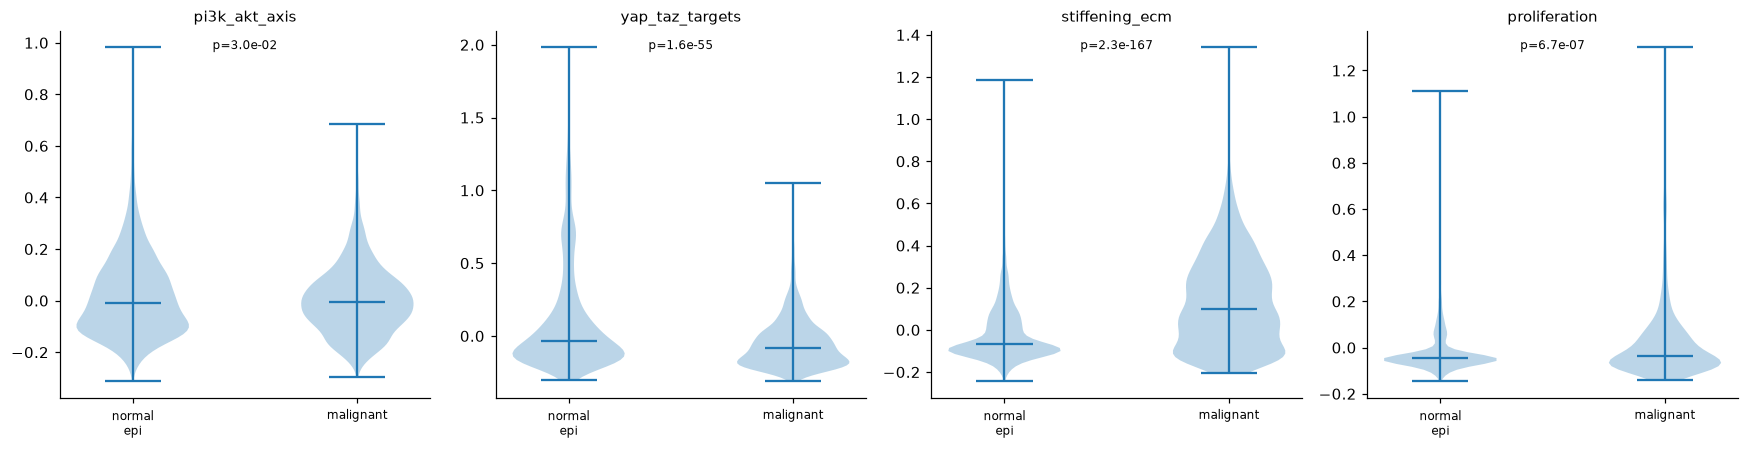

In [9]:
DEPTH_FLOOR = epi["total_counts"].quantile(0.25)      # drop the shallowest quartile (confound-prone)
CLEAN_TUMORS = ["LUNG_T18", "LUNG_T28", "LUNG_T30", "LUNG_T20"]

# score model-node signatures on the epithelial compartment (common scale), then compare groups
SIGS = {
  "pi3k_akt_axis":   ["AKT1","PIK3CA","PDPK1","FOXO3","GSK3B","RPS6KB1"],
  "yap_taz_targets": ["CTGF","CCN2","CYR61","CCN1","ANKRD1","AMOTL2","THBS1","CAV1","TEAD1"],
  "stiffening_ecm":  ["COL1A1","COL1A2","COL3A1","FN1","ELN","FBN1"],
  "proliferation":   ["MKI67","TOP2A","PCNA","CCNB1","CDK1","BIRC5"],
}
# score on the whole epithelial compartment so malignant and normal share one scale,
# then split into groups afterwards
A_epi = A[A.obs["cell_type"]=="Epithelial"].copy()
for name, genes in SIGS.items():
    used = score_sig(A_epi, genes, name)
    print(f"{name}: scored on {len(used)}/{len(genes)} genes")

e = A_epi.obs.copy()
e["group"] = np.where((e.cnv_status=="malignant") & (e.donor_id.isin(CLEAN_TUMORS)) & (e.total_counts>=DEPTH_FLOOR),
                      "malignant (high-conf)",
              np.where(e.condition=="normal", "normal epithelium", "other"))
keep = e[e.group.isin(["malignant (high-conf)","normal epithelium"])]
print(f"\nhigh-confidence malignant: {(keep.group=='malignant (high-conf)').sum()} cells | "
      f"normal epithelium: {(keep.group=='normal epithelium').sum()} cells")

fig, axes = plt.subplots(1, len(SIGS), figsize=(4*len(SIGS), 4.2), sharey=False)
for ax, name in zip(axes, SIGS):
    data = [keep.loc[keep.group==grp, name].values for grp in ["normal epithelium","malignant (high-conf)"]]
    parts = ax.violinplot(data, showmedians=True)
    ax.set_xticks([1,2]); ax.set_xticklabels(["normal\nepi","malignant"], fontsize=8)
    ax.set_title(name, fontsize=10)
    u, p = mannwhitneyu(data[1], data[0], alternative="two-sided")
    ax.text(0.5, 0.95, f"p={p:.1e}", transform=ax.transAxes, ha="center", fontsize=8)
plt.tight_layout(); plt.show()

**Read-out.** Scored on malignant cells specifically (high-confidence, depth-controlled) against
normal-lung epithelium:

- **`proliferation` up in malignant cells (p ≈ 7e-7).** The positive control. Cancer cells cycle
  more than normal epithelium, and seeing that confirms the malignant calls are behaving like tumor
  cells rather than like noise.
- **`stiffening_ecm` sharply up in malignant cells (p ≈ 2e-167), and it is not the stiffness
  response.** `stiffening_ecm` is a collagen and ECM *production* signature, which is a stromal
  program. Epithelial cells scoring high on it points toward EMT-like states or residual
  stromal/ambient contamination in the malignant calls, not toward mechanosensing. The p-value is
  enormous and it is answering a question nobody asked. This panel is not model support.
- **`yap_taz_targets` lower in malignant cells (p ≈ 1e-55)** and **`pi3k_akt_axis` flat**, where the
  nominal p ≈ 0.03 is large-n inflation and the violins are very nearly superimposable. These two
  are the model-relevant nodes, and in Kim's bulk treatment-naïve cancer cells the
  mechanotransduction response is not elevated.

Worth being careful about what that last point does and does not cost the model. The model concerns
drug-tolerant persisters under treatment, a subpopulation that Kim, being treatment-naïve and
dissociated, has no way to resolve. A flat YAP and AKT signal averaged over bulk malignant cells is
consistent with a response that switches on only in the tolerant subset under drug. It is also
consistent with the model being wrong. Kim cannot separate those two, and leaning either way here
would be reading more out of the data than is in it.

## 5: The CAF bridge — does the v1 stiffening niche reappear in tumor stroma?

The epithelial compartment was thin and depth-confounded. The fibroblast compartment is neither:
roughly 3,400 fibroblasts, well sampled in both tumor and normal lung, and no CNV calling anywhere
in sight, so none of section 3's problems follow us here.

Two scores go onto that compartment, the v1 stiffening program and a pathologic-CAF score built from
the v1 CTHRC1⁺ markers (CTHRC1, POSTN, COMP, and the collagens). Then tumor against normal, per
donor, restricted to samples carrying enough fibroblasts for a donor mean to mean anything.

stiffening_ecm: scored on 6/6 genes
pathologic_caf: scored on 5/5 genes
yap_taz_targets: scored on 5/9 genes

samples with >=20 fibroblasts: 17 (10 tumor, 7 normal)


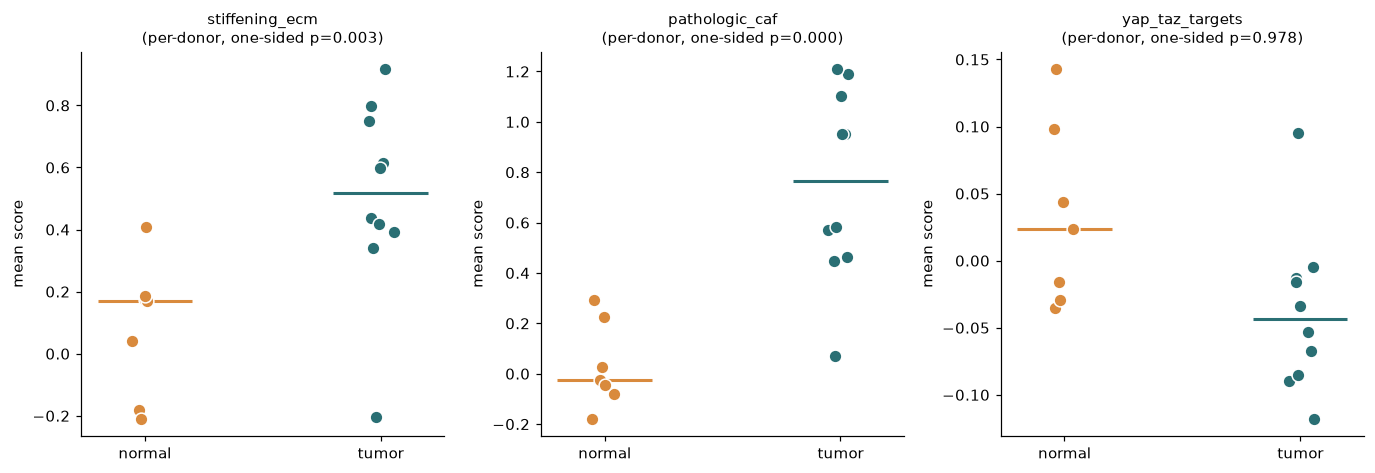

                    stiffening_ecm  pathologic_caf  yap_taz_targets
condition donor_id                                                 
normal    LUNG_N08          -0.182          -0.178            0.098
          LUNG_N09           0.171           0.225            0.044
          LUNG_N18          -0.209          -0.081           -0.016
          LUNG_N19           0.171          -0.024            0.143
          LUNG_N30           0.185           0.026           -0.035
          LUNG_N31           0.407           0.292           -0.029
          LUNG_N34           0.042          -0.046            0.023
tumor     LUNG_T06           0.341           0.570           -0.053
          LUNG_T08          -0.203           0.071           -0.118
          LUNG_T09           0.749           0.950            0.095
          LUNG_T18           0.616           1.191           -0.067
          LUNG_T19           0.439           0.447           -0.005
          LUNG_T25           0.798           0.9

In [10]:
A_fib = A[A.obs["cell_type"]=="Fibroblast"].copy()
FIB_SIGS = {
  "stiffening_ecm":  ["COL1A1","COL1A2","COL3A1","FN1","ELN","FBN1"],
  "pathologic_caf":  ["CTHRC1","POSTN","COMP","COL1A1","COL3A1"],   # v1 CTHRC1+ pathologic markers
  "yap_taz_targets": ["CTGF","CCN2","CYR61","CCN1","ANKRD1","AMOTL2","THBS1","CAV1","TEAD1"],
}
for name, genes in FIB_SIGS.items():
    used = score_sig(A_fib, genes, name)
    print(f"{name}: scored on {len(used)}/{len(genes)} genes")

# per-donor mean score: the donor is the replication unit, and a donor mean over
# fewer than MIN_FIB cells is too noisy to be one
MIN_FIB = 20
f = A_fib.obs.copy()
counts = f.groupby("donor_id", observed=True).size()
ok = counts[counts >= MIN_FIB].index
f = f[f.donor_id.isin(ok)]
print(f"\nsamples with >={MIN_FIB} fibroblasts: {len(ok)} "
      f"({(f.groupby('donor_id',observed=True).condition.first()=='tumor').sum()} tumor, "
      f"{(f.groupby('donor_id',observed=True).condition.first()=='normal').sum()} normal)")

per_donor = f.groupby(["condition","donor_id"], observed=True)[list(FIB_SIGS)].mean()

fig, axes = plt.subplots(1, len(FIB_SIGS), figsize=(4.2*len(FIB_SIGS), 4.4))
for ax, name in zip(axes, FIB_SIGS):
    vals = {c: per_donor.xs(c, level="condition")[name].values for c in ["normal","tumor"]}
    for i,(c,col) in enumerate([("normal","#d98a3d"),("tumor","#2a6f74")]):
        y = vals[c]
        ax.scatter(np.full_like(y,i)+np.random.uniform(-.06,.06,len(y)), y, s=70, c=col, edgecolor="white", zorder=3)
        ax.hlines(np.median(y), i-.2, i+.2, color=col, lw=2)
    p = mannwhitneyu(vals["tumor"], vals["normal"], alternative="greater").pvalue
    ax.set_xticks([0,1]); ax.set_xticklabels(["normal","tumor"])
    ax.set_title(f"{name}\n(per-donor, one-sided p={p:.3f})", fontsize=10); ax.set_ylabel("mean score")
plt.tight_layout(); plt.show()
print(per_donor.round(3).to_string())

**Read-out.** Scored on fibroblasts, tumor against normal, per donor, in samples carrying at least
20 fibroblasts:

- **`pathologic_caf`** (the v1 CTHRC1⁺, POSTN, and collagen markers) puts every tumor donor above
  nearly every normal donor, roughly 0.76 against −0.03, one-sided **p = 0.000**. That printed zero
  is the reporting floor at this sample size, not a real zero.
- **`stiffening_ecm`** comes in at 0.52 against 0.17, p = 0.003. The matrix-stiffening and ECM
  program is up in tumor CAFs.
- **`yap_taz_targets`** does not separate at all (p = 0.978, tumor marginally lower), which matches
  v1, where the fibroblast YAP signature was also flat. Whatever drives the ECM program here, the
  YAP target set is not reporting on it.

The ECM-production and pathologic-fibroblast program reappears in tumor stroma. Kim's fibroblasts
are building a stiff fibrotic niche around the tumor, which is the same thing v1 watched them do in
fibrotic lung.

### 5.1: Composition against cell-intrinsic

A score difference says tumor CAFs score higher on the stiffening program. It does not say why.
Tumors might simply contain more pathologic fibroblasts (compositional), or the fibroblasts present
might each be expressing the program harder (cell-intrinsic). Those carry different implications,
and the score on its own cannot separate them.

The same trick from v1 works here. Run pseudobulk DESeq2 tumor-against-normal twice, once across all
cells and once within fibroblasts only, then compare the two. A gene whose fold-change holds or grows
under restriction is cell-intrinsic; one that weakens was compositional all along. The heavy step
lives in `workflow/scripts/caf_de.py`, and the cell below reads its output CSVs and rebuilds the
figure.

composition vs cell-intrinsic (focus genes); LFC>0 = up in tumor CAFs:
        LFC_whole  padj_whole  LFC_fib  padj_fib  sharpens_in_fib
gene                                                             
CTHRC1      3.210       0.001    2.903     0.000            False
POSTN       1.221       0.243    2.957     0.052            False
COMP        2.652       0.028    2.717     0.042             True
COL1A1      2.024       0.058    2.011     0.005            False
COL3A1      3.984       0.000    2.244     0.001            False
COL1A2      2.468       0.001    0.943     0.167            False
FN1        -1.649       0.000    0.644     0.210            False
ELN         1.009       0.327    0.243     0.822            False
FBN1        0.905       0.247   -0.468     0.463            False
LOX         0.658       0.499    0.287     0.776            False
LOXL1       1.302       0.130    0.684     0.016            False
LOXL2       2.201       0.000    2.838     0.001             True
ACTA2

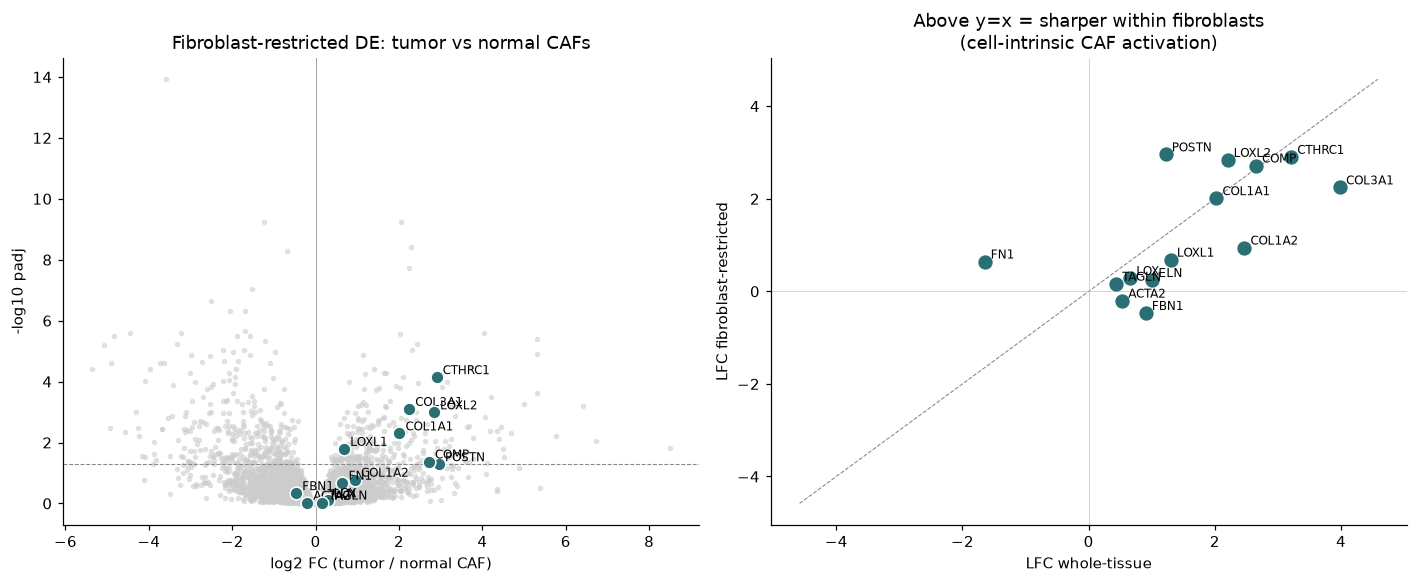

In [11]:

from pathlib import Path
de_dir = Path("results_kim/de")     # produced by workflow/scripts/caf_de.py
res_fib = pd.read_csv(de_dir / "caf_fibroblast_de.csv", index_col=0)
comp    = pd.read_csv(de_dir / "caf_focus_comparison.csv", index_col=0)

print("composition vs cell-intrinsic (focus genes); LFC>0 = up in tumor CAFs:")
print(comp.round(3).to_string())

FOCUS = comp.index.tolist()
rf = res_fib.dropna(subset=["padj"]).copy()
rf["nlp"] = -np.log10(rf["padj"].clip(lower=1e-300))

fig, ax = plt.subplots(1, 2, figsize=(13, 5.4))
# (left) fibroblast-restricted volcano, v1 stiffening genes highlighted
ax[0].scatter(rf["log2FoldChange"], rf["nlp"], s=7, c="#cccccc", alpha=.5)
for g in FOCUS:
    if g in rf.index:
        r = rf.loc[g]
        ax[0].scatter(r["log2FoldChange"], r["nlp"], s=70, c="#2a6f74", zorder=3, edgecolor="white")
        ax[0].annotate(g, (r["log2FoldChange"], r["nlp"]), fontsize=8, xytext=(4, 2), textcoords="offset points")
ax[0].axhline(-np.log10(0.05), ls="--", lw=.7, c="#888"); ax[0].axvline(0, lw=.5, c="#888")
ax[0].set_xlabel("log2 FC (tumor / normal CAF)"); ax[0].set_ylabel("-log10 padj")
ax[0].set_title("Fibroblast-restricted DE: tumor vs normal CAFs")
# (right) whole-tissue vs fibroblast LFC - above y=x = sharper within fibroblasts (cell-intrinsic)
c = comp.dropna(subset=["LFC_whole", "LFC_fib"])
ax[1].scatter(c["LFC_whole"], c["LFC_fib"], s=70, c="#2a6f74", zorder=3)
for g, r in c.iterrows():
    ax[1].annotate(g, (r["LFC_whole"], r["LFC_fib"]), fontsize=8, xytext=(4, 2), textcoords="offset points")
lim = np.nanmax(np.abs(np.r_[c["LFC_whole"], c["LFC_fib"]])) * 1.15
ax[1].plot([-lim, lim], [-lim, lim], ls="--", lw=.7, c="#888")
ax[1].axhline(0, lw=.4, c="#bbb"); ax[1].axvline(0, lw=.4, c="#bbb")
ax[1].set_xlabel("LFC whole-tissue"); ax[1].set_ylabel("LFC fibroblast-restricted")
ax[1].set_title("Above y=x = sharper within fibroblasts\n(cell-intrinsic CAF activation)")
plt.tight_layout(); plt.show()


**Read-out.** Cell-intrinsic, as far as this design can tell.

The fibroblast-restricted DE is significant for the core v1 program. CTHRC1 is strongly up in tumor
CAFs (LFC ≈ 3, padj ≈ 6e-5), with COL3A1, LOXL2, and COL1A1 also significant; POSTN and COMP rise by
a similar magnitude and sit right at the significance boundary. The right panel is what actually
carries the argument, though. Nearly every pathologic gene lies on or above the y = x line, which
means the tumor-versus-normal fold-change is as large or larger within fibroblasts than across whole
tissue. Purely compositional signal does the opposite: if these genes were up only because tumors
hold more fibroblasts, holding the fibroblast fraction fixed would push them below the line.

FN1 is the exception, down in whole tissue and up within fibroblasts. The myofibroblast-contractility
controls (ACTA2, TAGLN) sit near the origin, which is informative in its own quiet way, since it
means the tumor-versus-normal CAF difference is carried by the CTHRC1⁺ collagen and
matrix-deposition program specifically and not by a generic shift toward contractility. v1 found the
same division of labor.

So NSCLC tumor-associated fibroblasts cell-intrinsically activate the same CTHRC1⁺ collagen and
stiffening program that defines pathologic fibroblasts in pulmonary fibrosis. It survives DESeq2, it
survives restriction to fibroblasts, and it is not a compositional artifact.

The v1 caveat applies here with a little more force. Tumor CAFs and normal-lung fibroblasts are
partly different populations to begin with, since normal lung carries alveolar and adventitial
fibroblasts where tumors carry CAFs, so "cell-intrinsic activation" still contains a population-shift
component. A finer follow-up could use Kim's own `Cell_subtype` labels to split subtype proportion
from per-cell expression, which I have not done here.

## 6: Niche and response are two different measurements

The model predicts a stiffness-dependent response in the cancer cells: stiff matrix, then raised
FAK/AKT and YAP/TAZ signaling in malignant cells, then a drug-tolerant state. Sections 4 and 5 are
easy to read as though both were about that. They are not, and keeping them apart matters.

- **Section 5 measures the stroma.** The stiffening and pathologic programs are scored on
  fibroblasts. More activated tumor CAFs means the niche is being built.
- **Section 4 measures the cancer cells.** YAP and AKT are scored on malignant cells specifically
  (`cnv_status == "malignant"`, high-confidence, depth-controlled).

If the niche drives the response, tumors with stiffer CAF niches ought to contain malignant cells
with more mechanoresponse. The obstacle is that scRNA-seq is dissociated, so which malignant cell sat
beside which CAF is information destroyed at the bench, before any of this. What survives is a
per-sample version of the question: does a sample's CAF stiffening predict its malignant cells' YAP
and AKT?

That is the right question, and the closest Kim can get to the model's core claim. It is also badly
underpowered, since only a few tumor samples carry both enough malignant cells and enough
fibroblasts, so what follows is exploratory and labeled that way in the figure itself.

tumor samples with >=20 CAFs AND >=30 malignant cells: 9
          caf_stiffening  pi3k_akt_axis  yap_taz_targets
donor_id                                                
LUNG_T06           0.341          0.045            0.075
LUNG_T08          -0.203          0.018           -0.051
LUNG_T18           0.616          0.023           -0.077
LUNG_T19           0.439         -0.021           -0.049
LUNG_T25           0.798         -0.019           -0.058
LUNG_T28           0.598          0.001           -0.113
LUNG_T30           0.417         -0.015            0.133
LUNG_T31           0.916          0.023            0.065
LUNG_T34           0.391         -0.022           -0.023


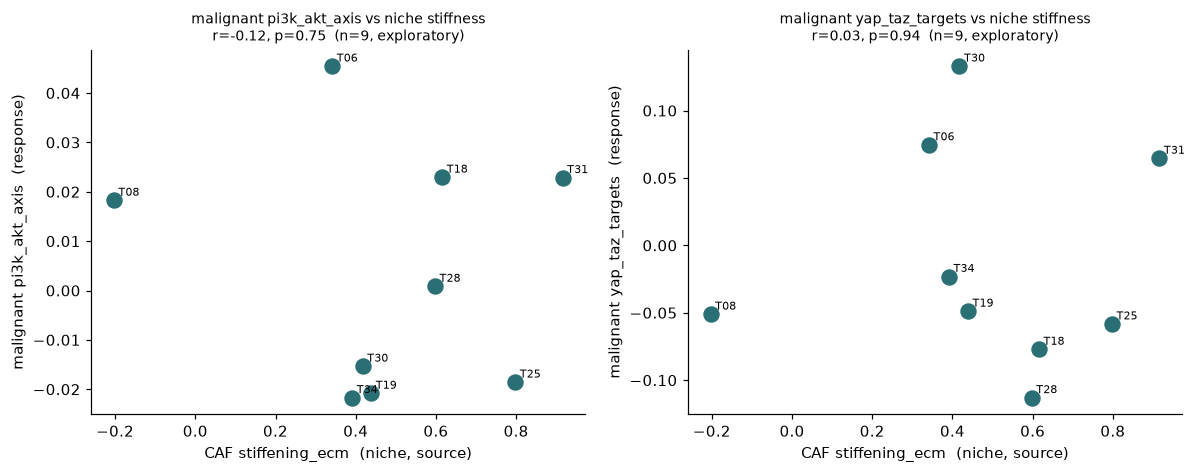

In [12]:

# Niche (CAF stiffening) vs response (malignant-cell YAP/AKT), per tumor sample.
# Requires §4 (A_epi, scored) and §5 (A_fib, scored) to have run first.
from scipy.stats import pearsonr

MIN_MAL, MIN_FIB = 30, 20
ie  = A_epi.obs    # has pi3k_akt_axis, yap_taz_targets, cnv_status, donor_id, condition
ifb = A_fib.obs    # has stiffening_ecm, pathologic_caf, donor_id, condition

# per-sample CAF niche stiffness (tumor samples with enough fibroblasts)
caf_grp  = ifb[ifb.condition == "tumor"].groupby("donor_id", observed=True)
caf_keep = caf_grp.size()[caf_grp.size() >= MIN_FIB].index
niche    = caf_grp["stiffening_ecm"].mean().loc[caf_keep]

# per-sample malignant-cell response (tumor samples with enough malignant cells)
mal_grp  = (ie[(ie.condition == "tumor") & (ie.cnv_status == "malignant")]
            .groupby("donor_id", observed=True))
mal_keep = mal_grp.size()[mal_grp.size() >= MIN_MAL].index
resp     = mal_grp[["pi3k_akt_axis", "yap_taz_targets"]].mean().loc[mal_keep]

df = niche.to_frame("caf_stiffening").join(resp, how="inner")
print(f"tumor samples with >={MIN_FIB} CAFs AND >={MIN_MAL} malignant cells: {len(df)}")
print(df.round(3).to_string())

if len(df) >= 3:
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
    for a, col in zip(ax, ["pi3k_akt_axis", "yap_taz_targets"]):
        a.scatter(df["caf_stiffening"], df[col], s=95, c="#2a6f74", zorder=3)
        for s, row in df.iterrows():
            a.annotate(s.replace("LUNG_", ""), (row["caf_stiffening"], row[col]),
                       fontsize=7, xytext=(3, 3), textcoords="offset points")
        r, p = pearsonr(df["caf_stiffening"], df[col])
        a.set_title(f"malignant {col} vs niche stiffness\nr={r:.2f}, p={p:.2f}  (n={len(df)}, exploratory)", fontsize=9)
        a.set_xlabel("CAF stiffening_ecm  (niche, source)")
        a.set_ylabel(f"malignant {col}  (response)")
    plt.tight_layout(); plt.show()
else:
    print("\nToo few samples with both compartments well-sampled to plot a correlation.")
    print("This is the expected Kim limitation - the definitive test needs Maynard.")


**Read-out (exploratory).** With only a handful of qualifying samples, this correlation cannot
confirm or reject the niche-to-response link, and it should not be asked to. A positive slope would
be suggestive, hinting that stiffer-niche tumors carry more mechano-active cancer cells. A flat or
negative one is uninformative at this n rather than evidence against.

The limits here are structural and no amount of cleverness in the analysis fixes them: too few
cancer cells per sample, no treatment axis, and no persister states anywhere in the dataset.

## 7: Conclusions and next steps

1. **TME landscape.** The tumor-versus-normal compositional shift across the NSCLC
   microenvironment, comparable per sample at 11 against 11.
2. **CNV malignant calling.** Works at the cohort level and validates against normal epithelium,
   with its depth-driven false-positive confound measured rather than assumed away (r = −0.79).
3. **The CAF bridge.** The v1 CTHRC1⁺ stiffening niche reappears in NSCLC tumor stroma. Per donor,
   `pathologic_caf` runs about 0.76 against −0.03 (p ≈ 0) and `stiffening_ecm` 0.52 against 0.17
   (p = 0.003). Fibroblast-restricted DESeq2 shows this is cell-intrinsic CAF activation, with
   CTHRC1 and the collagens sharpening within fibroblasts at padj significance, rather than a
   compositional artifact.
4. **Tumor-intrinsic response.** Scored on the cancer cells specifically, the mechanotransduction
   response is not elevated in Kim's bulk treatment-naïve malignant cells: YAP lower, AKT flat,
   proliferation up as the positive control.

Kim splits the model down the middle, and the split is the useful part. The niche half is supported,
since CAFs demonstrably build stiffness and do it per cell rather than by arriving in greater
numbers. The response half is not, because Kim's epithelium is sparse, depth-confounded, and
treatment-naïve. Those are properties of the dataset and not verdicts on the model, and the whole
value of this notebook is knowing which of the two you are looking at.

**What comes next.** The fibroblast-restricted DE in section 5.1 started out on this list as future
work; it is done, and it is what turned the CAF bridge from a score difference into a mechanistic
claim. What remains is Maynard, which is Smart-seq2, so the depth confound does not follow us, and
which finally has a treatment axis with persister states on it. Whether that axis can test a
stiffness prediction is a separate question, and v3 spends most of its length on exactly that.